In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from backtester.strategy import get_data, generate_signals, backtest, calculate_metrics

In [2]:
df = get_data("AAPL", "2020-01-01", "2026-01-01")
df = generate_signals(df)
df = backtest(df)
metrics = calculate_metrics(df)
print(metrics)

[*********************100%***********************]  1 of 1 completed

{'Total Return': '58.73%', 'CAGR': '8.03%', 'Sharpe Ratio': '0.49', 'Max Drawdown': '-35.66%'}


In [3]:
buy_hold_return = (df["Close"].iloc[-1] / df["Close"].iloc[0] - 1) * 100
print(f"Buy and Hold Return: {buy_hold_return:.2f}%")

Buy and Hold Return: 275.14%


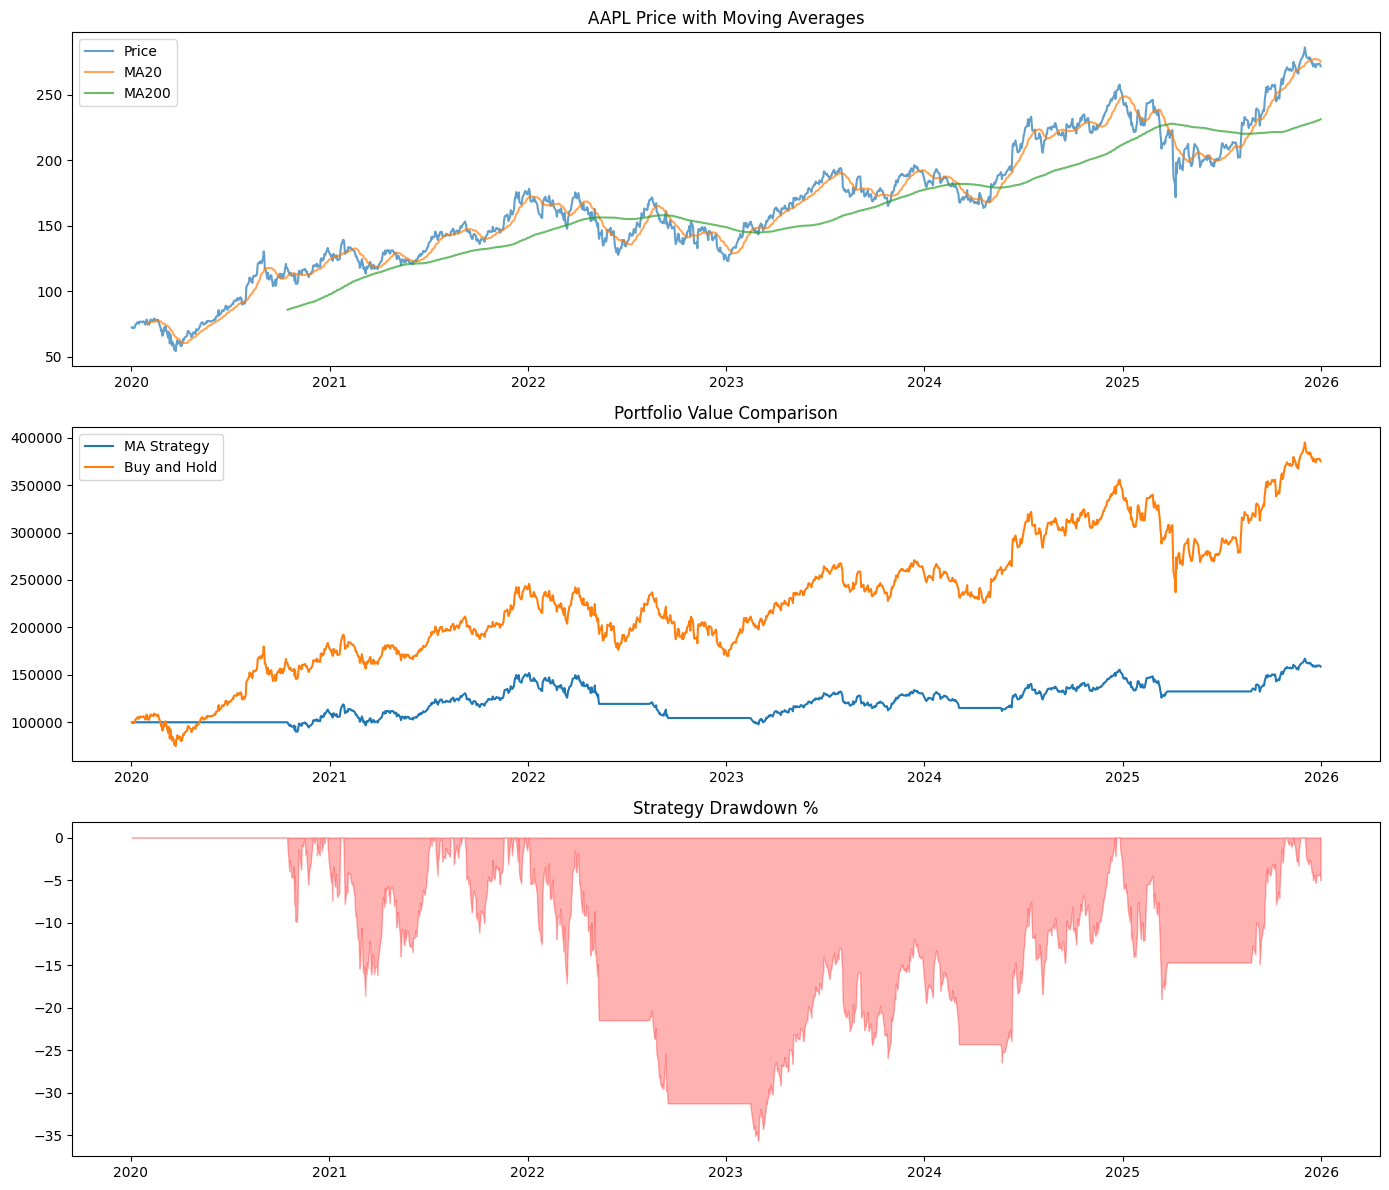

In [4]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))

# Price with MAs
ax1.plot(df.index, df["Close"], label="Price", alpha=0.7)
ax1.plot(df.index, df["MA_20"], label="MA20", alpha=0.7)
ax1.plot(df.index, df["MA_200"], label="MA200", alpha=0.7)
ax1.set_title("AAPL Price with Moving Averages")
ax1.legend()

#  Portfolio vs Buy and Hold
buy_hold_portfolio = (df["Close"] / df["Close"].iloc[0]) * 100000
ax2.plot(df.index, df["Portfolio"], label="MA Strategy")
ax2.plot(df.index, buy_hold_portfolio, label="Buy and Hold")
ax2.set_title("Portfolio Value Comparison")
ax2.legend()

# Drawdown
rolling_max = df["Portfolio"].cummax()
drawdown = (df["Portfolio"] - rolling_max) / rolling_max * 100
ax3.fill_between(df.index, drawdown, 0, alpha=0.3, color="red")
ax3.set_title("Strategy Drawdown %")

plt.tight_layout()
plt.show()